In [1]:
import numpy as np
import h5py

# =========================
# Parámetros
# =========================
NUM_FREQ = 672
NUM_ANTS = 32
BLOCK_SIZE = 2
NUM_RECEIVERS = NUM_ANTS // BLOCK_SIZE
NUM_BLOCKS = NUM_RECEIVERS * (NUM_RECEIVERS + 1) // 2   # 136
SAMPLES_PER_FRAME = 14976

GOOD_ANTS = set(range(8, 32))

GPU_PATH = "../gpu_corr_dump/frame_000.bin"
H5_PATH = "/hdd/32_test/260306T185135Z_CHARTS_hdf5/baseband_virtual.h5"
FRAME = 0

# =========================
# Utilidades CPU
# =========================
def unpack_4bit_complex(u8: np.ndarray) -> np.ndarray:
    real = (u8 >> 4).astype(np.int8)
    imag = (u8 & 0x0F).astype(np.int8)
    real[real >= 8] -= 16
    imag[imag >= 8] -= 16
    return real.astype(np.float32) + 1j * imag.astype(np.float32)

def load_cpu_chains(h5_path):
    with h5py.File(h5_path, "r") as f:
        packed = f["baseband"][:, :, :]   # esperado: (ant, freq, time)
    chains = unpack_4bit_complex(packed)
    return chains

def build_cpu_pair_dict(chains, frame=0, samples_per_frame=SAMPLES_PER_FRAME):
    t0 = frame * samples_per_frame
    t1 = (frame + 1) * samples_per_frame

    cpu_dict = {}
    for a in range(NUM_ANTS):
        xa = chains[a][:, t0:t1]   # (freq, time)
        for b in range(NUM_ANTS):
            xb = chains[b][:, t0:t1]
            vis = np.sum(xa * np.conj(xb), axis=1)   # (freq,)
            cpu_dict[(a, b)] = vis
    return cpu_dict

# =========================
# Utilidades GPU
# =========================
def load_gpu_frame_raw(path):
    raw = np.fromfile(path, dtype=np.int32)
    #raw = raw.astype(np.float32)  # para evitar overflow al convertir a complejo
    expected = NUM_FREQ * NUM_BLOCKS * 4 * 2
    assert raw.size == expected, f"Tamaño inesperado: {raw.size}, esperado {expected}"
    corr = raw.reshape(NUM_FREQ, NUM_BLOCKS, 4, 2)
    V = corr[..., 0] + 1j * corr[..., 1]   # (freq, block, k)
    return V



def build_receiver_groups(num_elements=NUM_ANTS, reverse_groups=False, swap_inside=False):
    """
    Devuelve una lista de grupos de 2 elementos.
    normal: [(0,1), (2,3), ..., (30,31)]
    reverse_groups: invierte numeración global -> [(31,30), (29,28), ...] antes de swap interno final
    swap_inside: intercambia orden dentro de cada grupo
    """
    groups = []
    for r in range(num_elements // 2):
        a0 = 2 * r
        a1 = 2 * r + 1
        groups.append((a0, a1))

    if reverse_groups:
        groups = [(num_elements - 1 - a0, num_elements - 1 - a1) for (a0, a1) in groups]

    if swap_inside:
        groups = [(a1, a0) for (a0, a1) in groups]

    return groups
def build_block_labels_lower(num_receivers=NUM_RECEIVERS):
    """
    Triángulo inferior:
    (0,0), (1,0), (1,1), (2,0), (2,1), (2,2), ...
    """
    block_labels = []
    for ry in range(num_receivers):
        for rx in range(ry + 1):
            block_labels.append((ry, rx))
    assert len(block_labels) == num_receivers * (num_receivers + 1) // 2
    return block_labels

def gpu_frame_to_pair_dict(Vgpu, reverse_groups=False, swap_inside=False):
    """
    Interpreta la salida GPU como:
      block -> (ry, rx) en triángulo inferior
      k = 2*py + px
      par escalar -> (a, b) con:
          a = groups[ry][py]
          b = groups[rx][px]
    """
    block_labels = build_block_labels_lower(NUM_RECEIVERS)
    groups = build_receiver_groups(NUM_ANTS, reverse_groups=reverse_groups, swap_inside=swap_inside)

    gpu_dict = {}

    for block, (ry, rx) in enumerate(block_labels):
        gy = groups[ry]
        gx = groups[rx]

        # k=0..3
        # 0 -> (py=0, px=0)
        # 1 -> (py=0, px=1)
        # 2 -> (py=1, px=0)
        # 3 -> (py=1, px=1)
        gpu_dict[(gy[0], gx[0])] = Vgpu[:, block, 0]
        gpu_dict[(gy[0], gx[1])] = Vgpu[:, block, 1]
        gpu_dict[(gy[1], gx[0])] = Vgpu[:, block, 2]
        gpu_dict[(gy[1], gx[1])] = Vgpu[:, block, 3]

    return gpu_dict

# =========================
# Métricas
# =========================
def phase_metrics(g, c, amp_percentile=70, min_points=20):
    g = np.asarray(g)
    c = np.asarray(c)

    ag = np.abs(g)
    ac = np.abs(c)

    thr_g = np.percentile(ag, amp_percentile)
    thr_c = np.percentile(ac, amp_percentile)

    mask = (ag > thr_g) & (ac > thr_c)

    if np.sum(mask) < min_points:
        return None

    gm = g[mask]
    cm = c[mask]

    phi0 = np.angle(np.sum(gm * np.conj(cm)))
    gm_al = gm * np.exp(-1j * phi0)

    dphi = np.angle(gm_al * np.conj(cm))

    rms_deg = np.sqrt(np.mean(dphi**2)) * 180 / np.pi
    coh = np.abs(np.mean(np.exp(1j * dphi)))

    return {
        "coh": coh,
        "rms_deg": rms_deg,
        "phi0_deg": phi0 * 180 / np.pi,
        "npts": int(np.sum(mask)),
    }


In [2]:
# CPU
chains = load_cpu_chains("/hdd/32_test/260306T185135Z_CHARTS_hdf5/baseband_virtual.h5")
cpu_dict = build_cpu_pair_dict(chains, frame=9)

In [61]:
# GPU
Vgpu = load_gpu_frame_raw("../gpu_corr_dump/frame_000.bin")
gpu_dict = gpu_frame_to_pair_dict(Vgpu, reverse_groups=True, swap_inside=False)

In [38]:
def normalize_all_pairs_to_ref(pair_dict, ref_key, eps=1e-12):
    norm_dict = {}

    for (i, j), vij in pair_dict.items():
        if ref_key not in pair_dict:
            continue

        vref = np.asarray(pair_dict[ref_key], dtype=np.complex64)
        vij = np.asarray(vij, dtype=np.complex64)

        bad = (~np.isfinite(vref)) | (np.abs(vref) < eps)

        out = np.full_like(vij, np.nan + 1j * np.nan)
        out[~bad] = vij[~bad] / vref[~bad]

        norm_dict[(i, j)] = out

    return norm_dict

In [41]:
cpu_dict_norm = normalize_all_pairs_to_ref(cpu_dict, ref_key=(15,23))
gpu_dict_norm = normalize_all_pairs_to_ref(gpu_dict, ref_key=(15,23))

In [47]:
labels = sorted(set(cpu_dict.keys()) & set(gpu_dict.keys()))
labels = [lab for lab in labels if lab[0] in range(8,32) and lab[1] in range(8,32) and lab[0] != lab[1]]

gpu_list = [gpu_dict[lab] for lab in labels]
cpu_list = [cpu_dict[lab] for lab in labels]

In [22]:
def phase_compare(g, c, amp_percentile=70, min_points=20):
    g = np.asarray(g)
    c = np.asarray(c)

    finite = (
        np.isfinite(g.real) & np.isfinite(g.imag) &
        np.isfinite(c.real) & np.isfinite(c.imag)
    )

    if np.sum(finite) < min_points:
        return None

    g = g[finite]
    c = c[finite]

    ag = np.abs(g)
    ac = np.abs(c)

    thr_g = np.percentile(ag, amp_percentile)
    thr_c = np.percentile(ac, amp_percentile)

    mask = (ag > thr_g) & (ac > thr_c)
    if np.sum(mask) < min_points:
        return None

    gm = g[mask]
    cm = c[mask]

    phi0 = np.angle(np.sum(gm * np.conj(cm)))
    gm_al = gm * np.exp(-1j * phi0)
    dphi = np.angle(gm_al * np.conj(cm))

    return {
        "phi0_deg": phi0 * 180 / np.pi,
        "rms_deg": np.sqrt(np.mean(dphi**2)) * 180 / np.pi,
        "coh": np.abs(np.mean(np.exp(1j * dphi))),
        "mask": mask,
    }

In [49]:
results = []

for lab, g, c in zip(labels, gpu_list, cpu_list):
    met = phase_compare(g, c)

    if met is None:
        continue

    results.append((lab, met["coh"], met["rms_deg"], met["phi0_deg"]))

results_sorted = sorted(results, key=lambda x: (-x[1], x[2]))

for r in results_sorted[:20]:
    print(r)

((20, 30), np.float64(0.9991126550104289), np.float64(2.4420850917228156), np.float64(-0.3118754205089982))
((16, 29), np.float64(0.9990852691778275), np.float64(2.4533607270280595), np.float64(0.185332826082986))
((8, 16), np.float64(0.9990560495005903), np.float64(2.491965082620356), np.float64(-0.0321129084455988))
((15, 23), np.float64(0.998933884690198), np.float64(2.646630824786755), np.float64(0.04100696123968204))
((16, 20), np.float64(0.9989318970394299), np.float64(2.6665814751209136), np.float64(-0.09144444858518687))
((12, 20), np.float64(0.9986004361450825), np.float64(3.0724163284925963), np.float64(0.05884263554720155))
((20, 24), np.float64(0.9985756225014121), np.float64(3.072204584583537), np.float64(-0.13932973349736297))
((8, 20), np.float64(0.9985532819509656), np.float64(3.0914605263665993), np.float64(0.2327341323896662))
((10, 27), np.float64(0.9985493775582591), np.float64(3.0967695429955118), np.float64(0.18698105209847438))
((24, 30), np.float64(0.99849675302

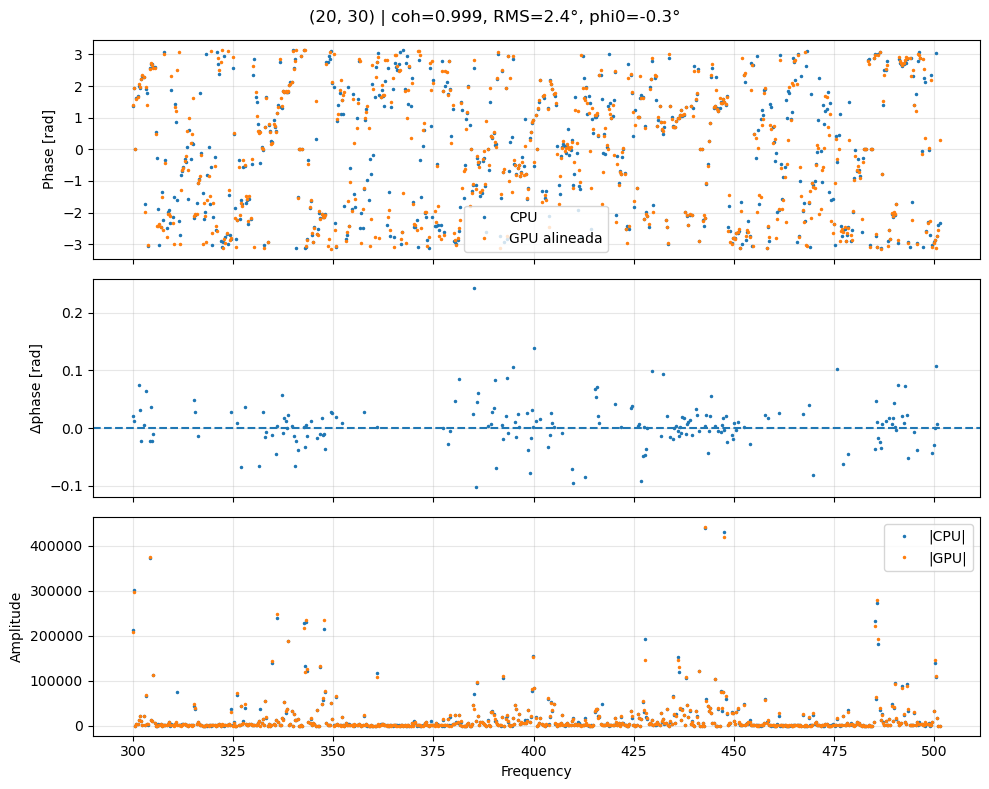

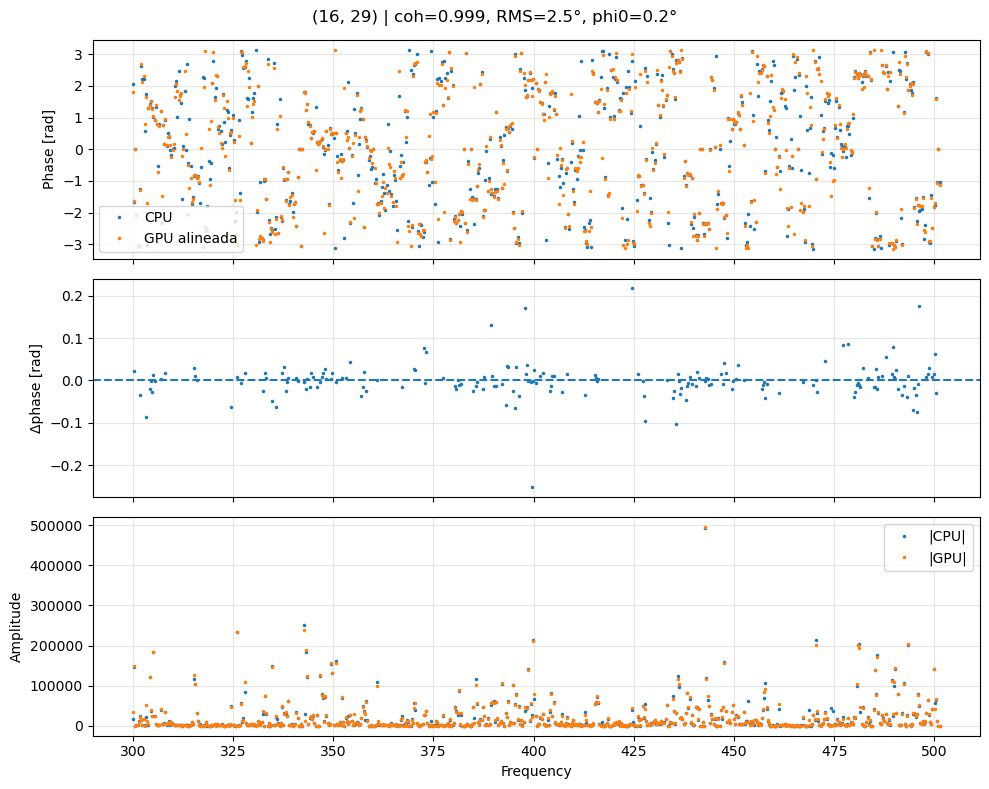

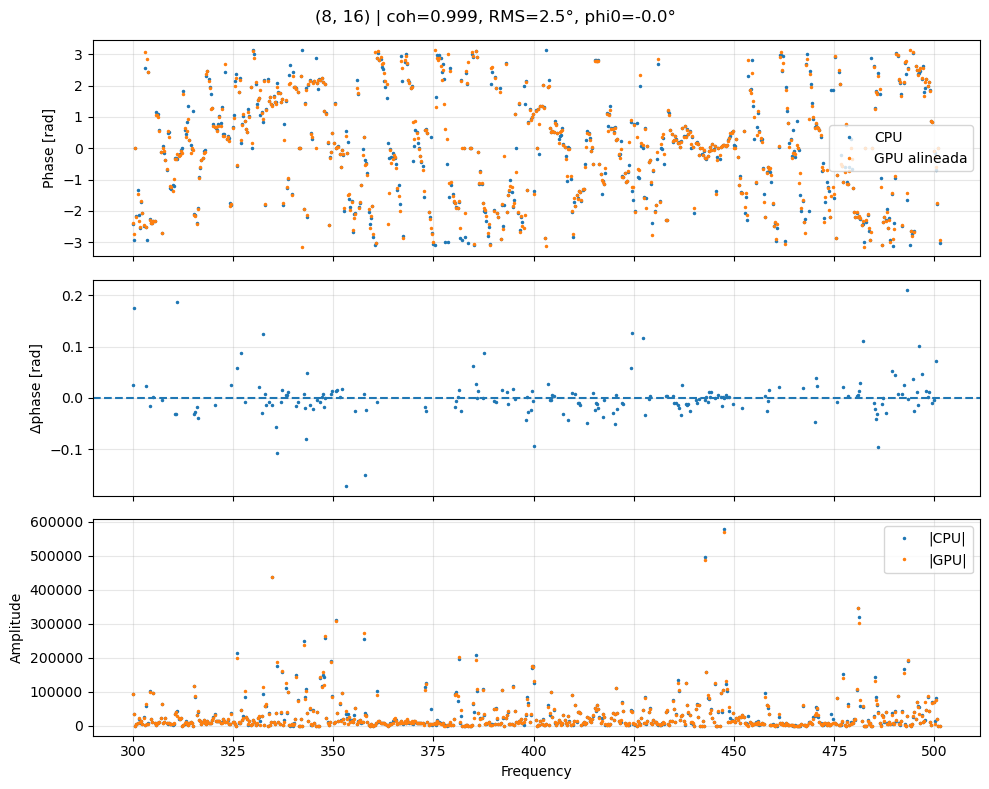

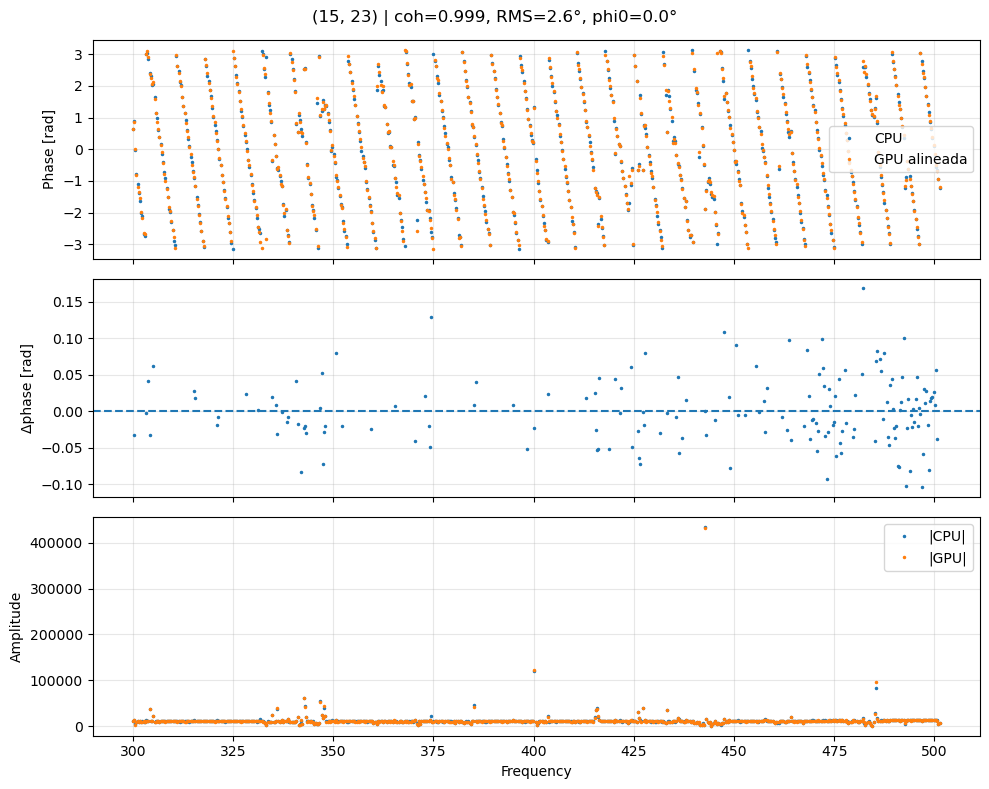

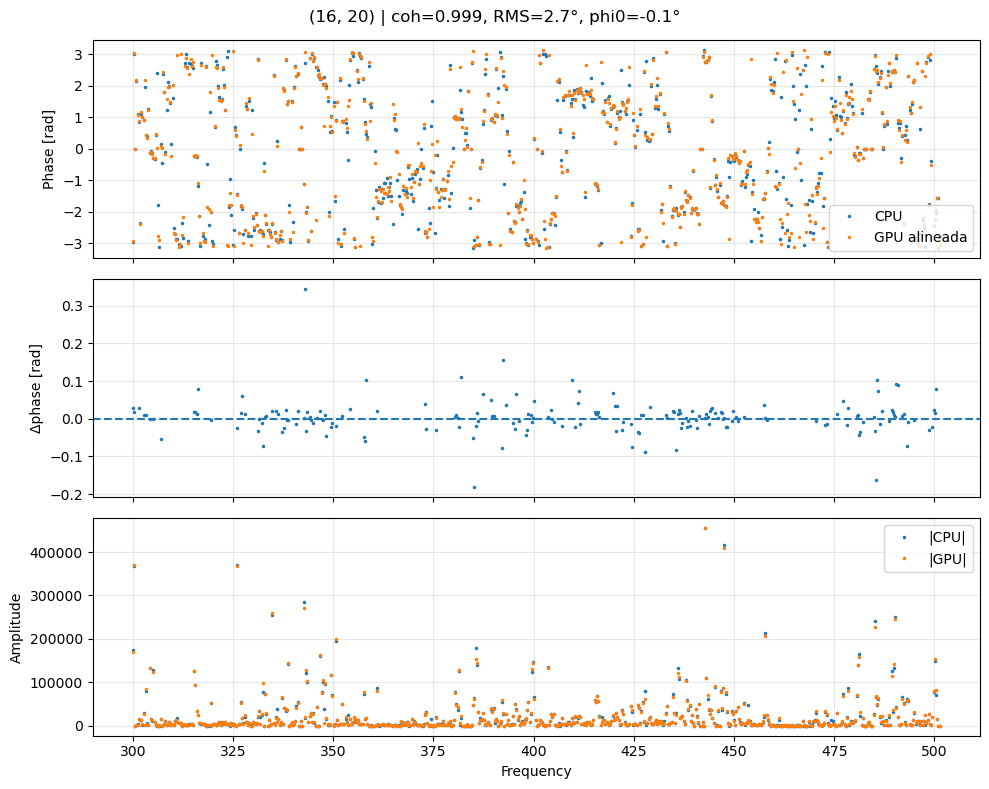

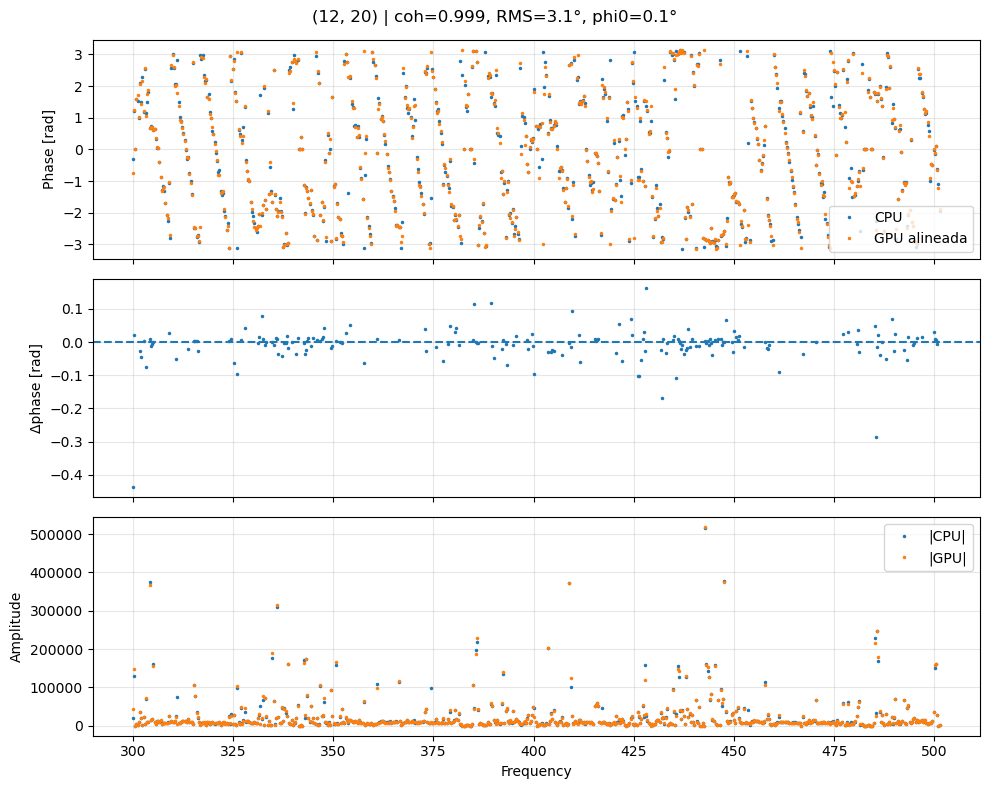

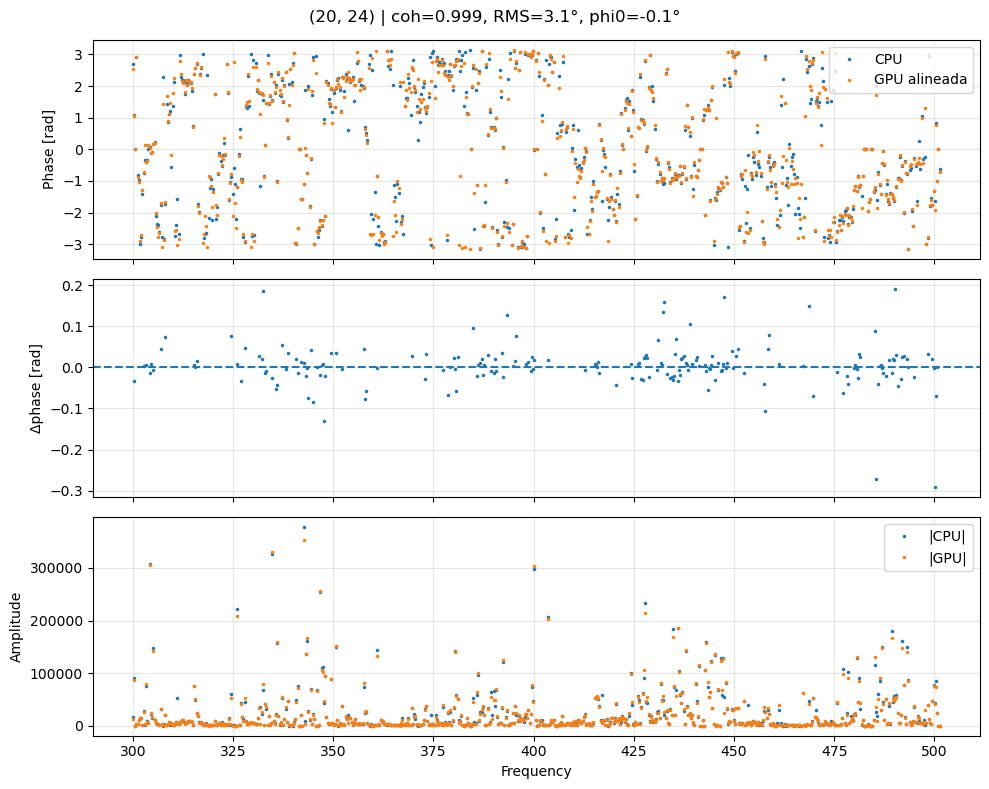

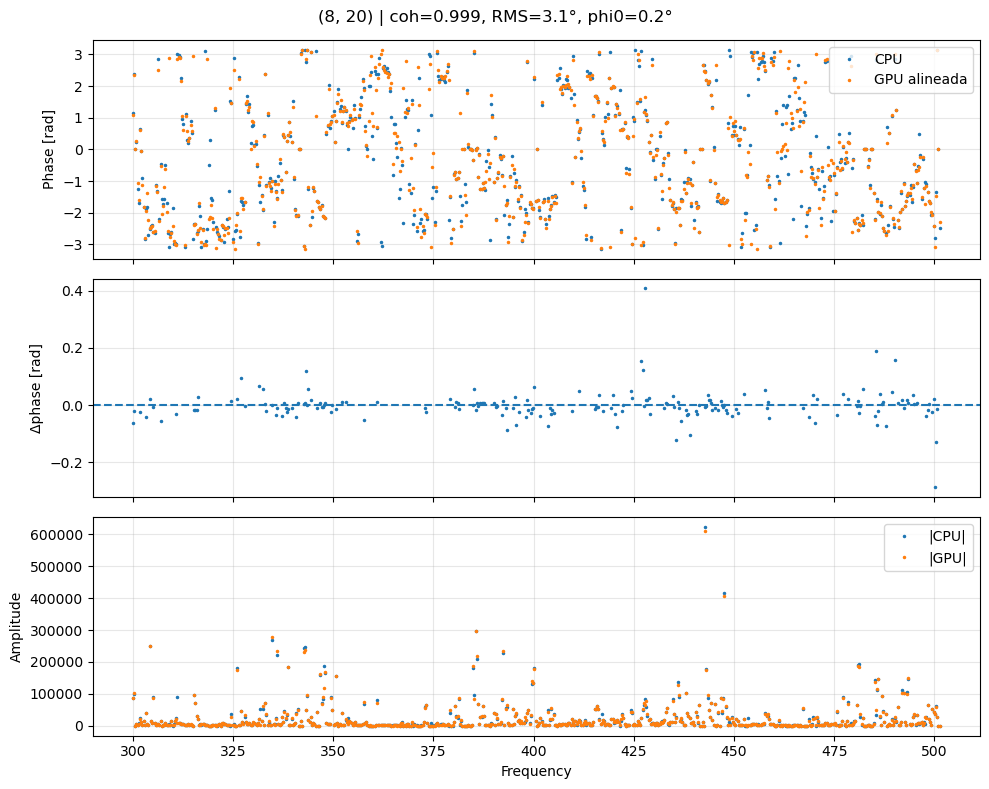

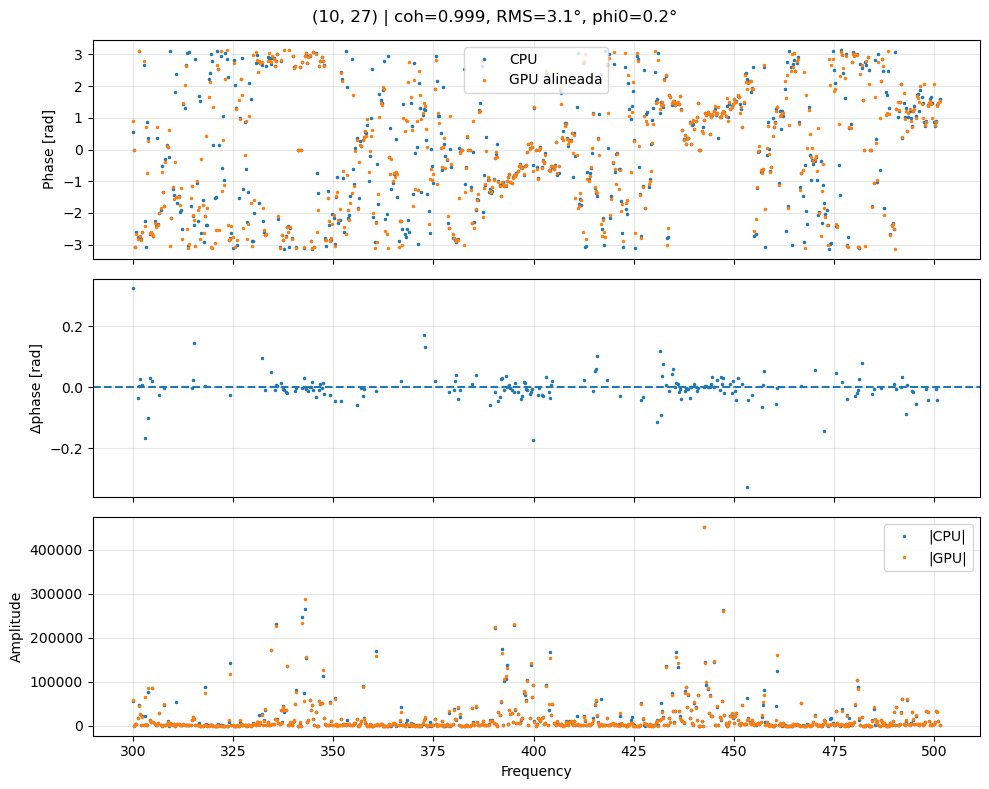

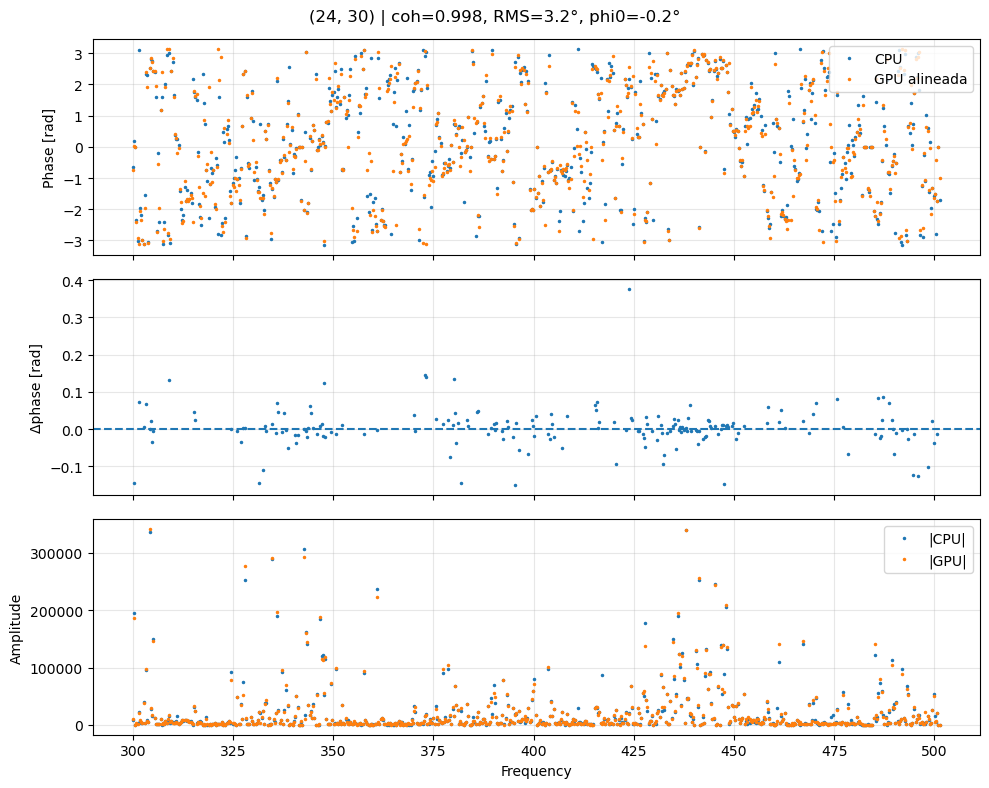

In [55]:
import matplotlib.pyplot as plt

frequencies = np.linspace(300, 501.6, 672, endpoint=False)  # Frequency axis

def plot_pair(label, gpu_dict, cpu_dict, amp_percentile=70, wrap_phase=True):
    g = gpu_dict[label]
    c = cpu_dict[label]

    met = phase_compare(g, c, amp_percentile=amp_percentile)
    if met is None:
        print("Muy pocos bins válidos")
        return

    ag = np.abs(g)
    ac = np.abs(c)

    thr_g = np.percentile(ag, amp_percentile)
    thr_c = np.percentile(ac, amp_percentile)
    mask = (ag > thr_g) & (ac > thr_c)

    phi0 = np.angle(np.sum(g[mask] * np.conj(c[mask])))
    g_al = g * np.exp(-1j * phi0)

    phase_g = np.unwrap(np.angle(g_al)) if wrap_phase else np.angle(g_al)
    phase_c = np.unwrap(np.angle(c)) if wrap_phase else np.angle(c)
    dphi = np.angle(g_al[mask] * np.conj(c[mask]))

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axs[0].plot(frequencies, phase_c, '.', ms=3, label='CPU')
    axs[0].plot(frequencies, phase_g, '.', ms=3, label='GPU alineada')
    axs[0].set_ylabel("Phase [rad]")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(frequencies[mask], dphi, '.', ms=3)
    axs[1].axhline(0, ls='--')
    axs[1].set_ylabel("Δphase [rad]")
    axs[1].grid(True, alpha=0.3)

    axs[2].plot(frequencies, np.abs(c), '.', ms=3, label='|CPU|')
    axs[2].plot(frequencies, np.abs(g), '.', ms=3, label='|GPU|')
    axs[2].set_ylabel("Amplitude")
    axs[2].set_xlabel("Frequency")
    axs[2].legend()
    axs[2].grid(True, alpha=0.3)

    fig.suptitle(
        f"{label} | coh={met['coh']:.3f}, RMS={met['rms_deg']:.1f}°, phi0={met['phi0_deg']:.1f}°"
    )
    plt.tight_layout()
    plt.show()

# Plot first 5 pairs
for lab, _, _, _ in results_sorted[:10]:
    plot_pair(lab, gpu_dict, cpu_dict, wrap_phase=False)

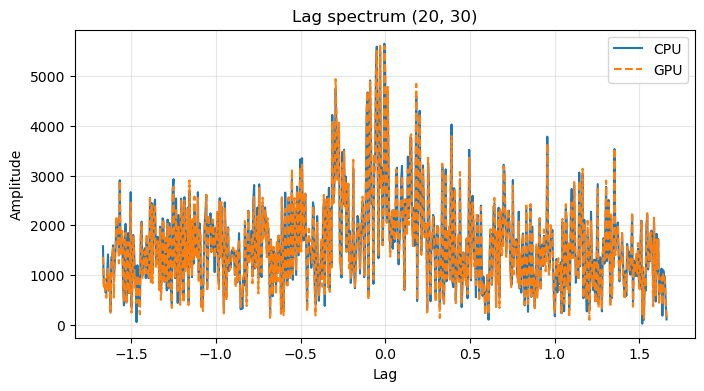

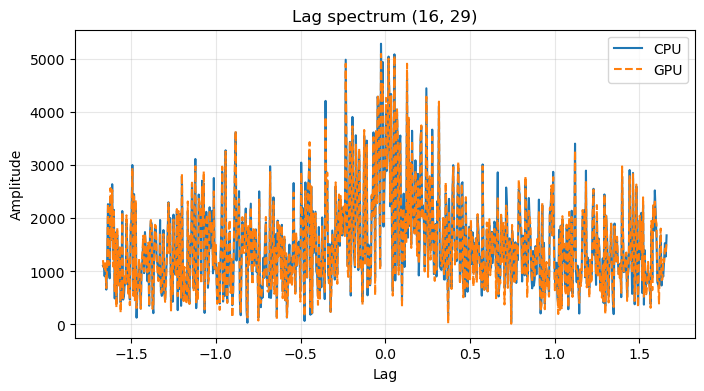

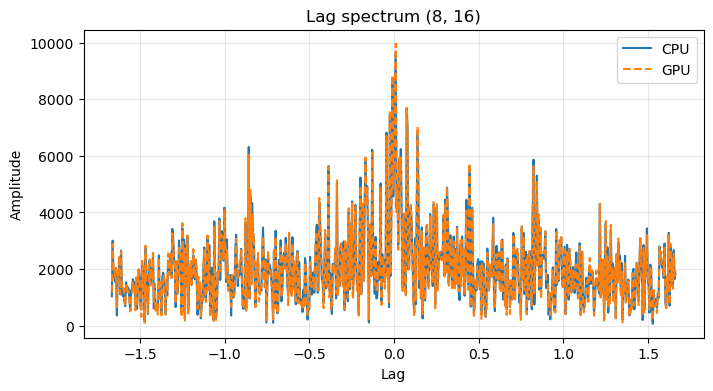

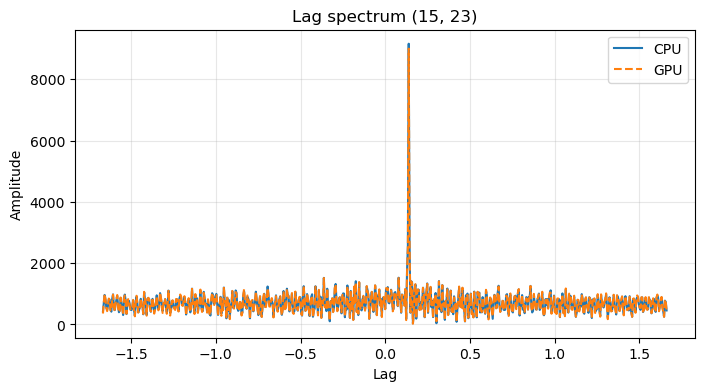

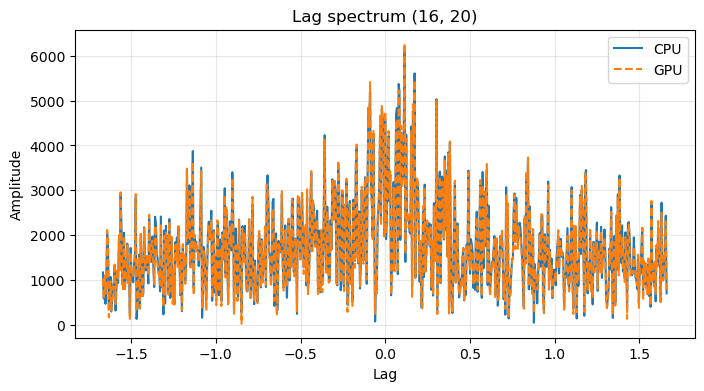

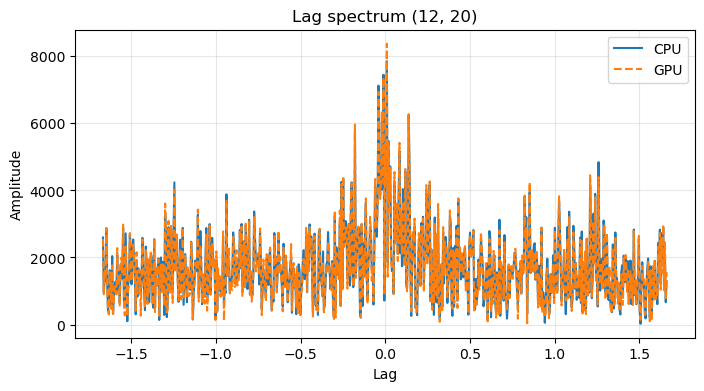

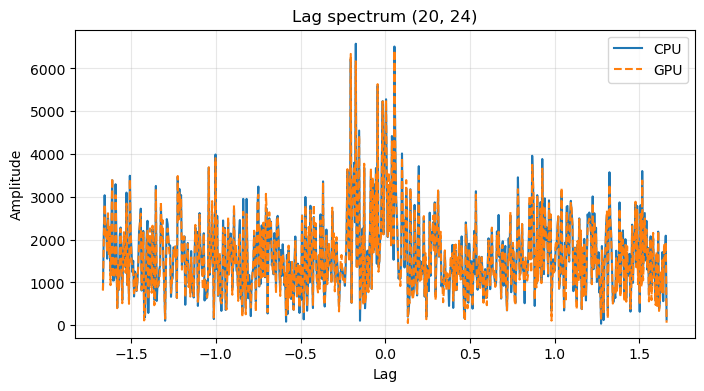

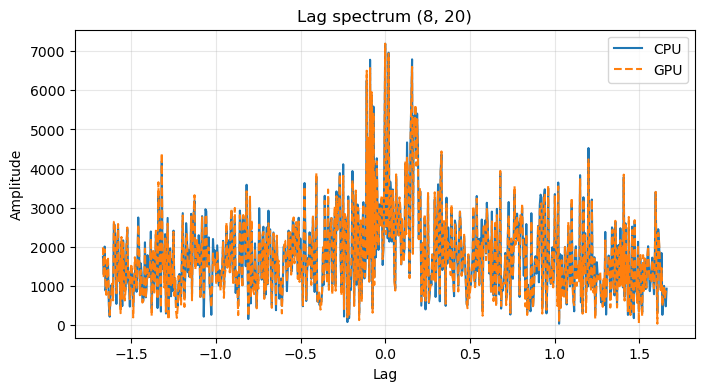

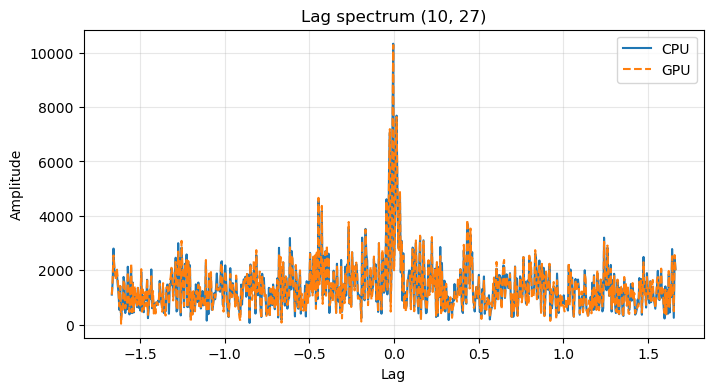

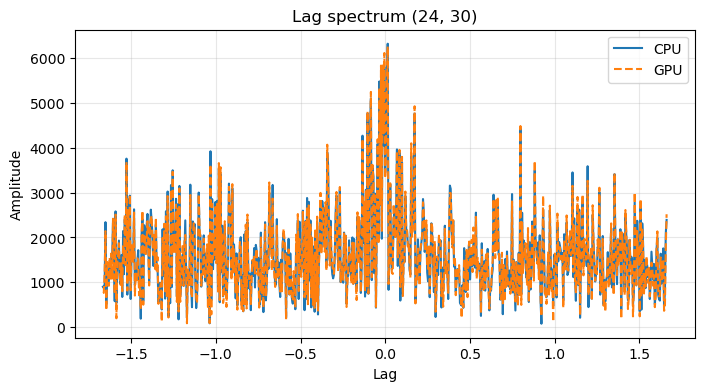

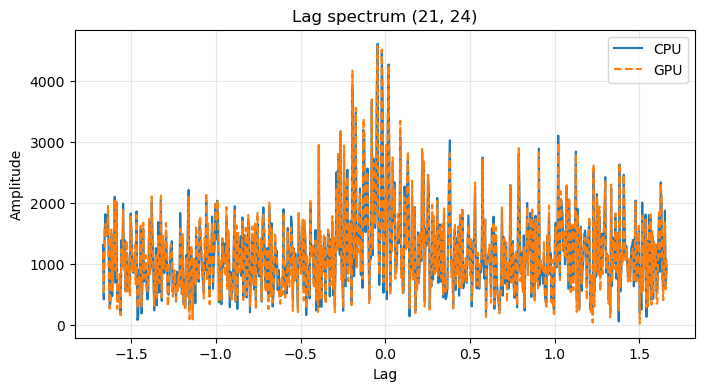

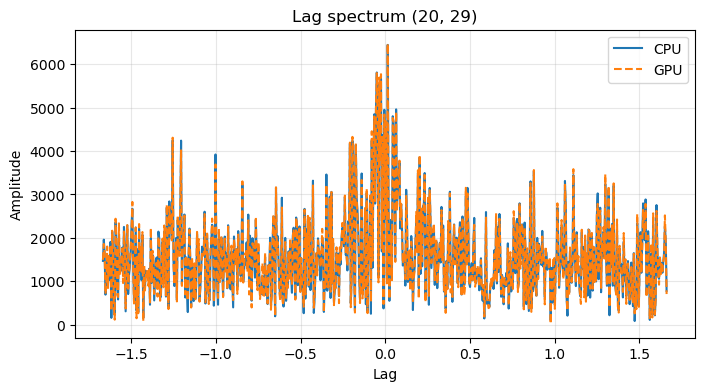

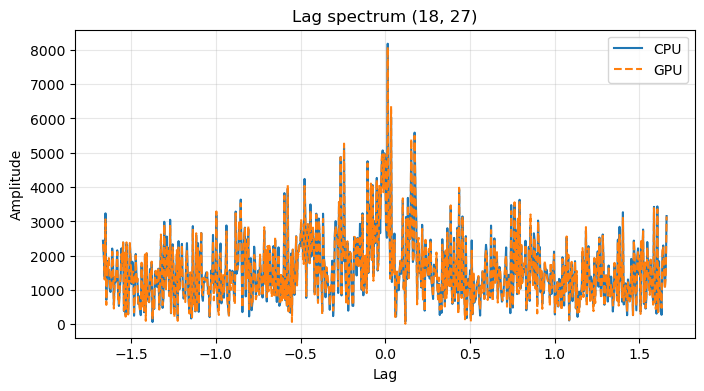

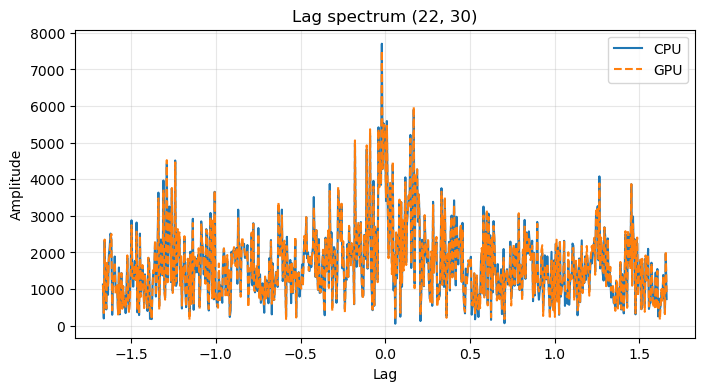

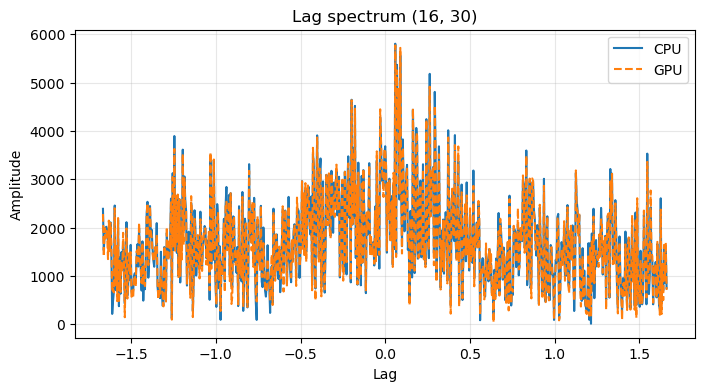

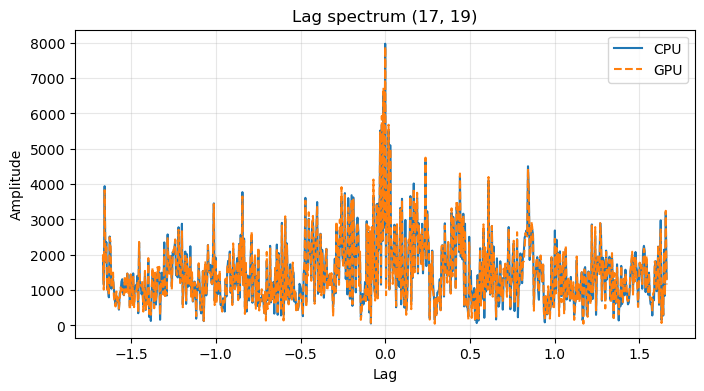

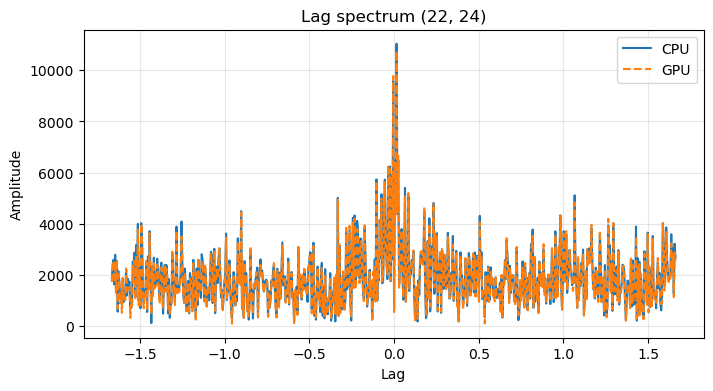

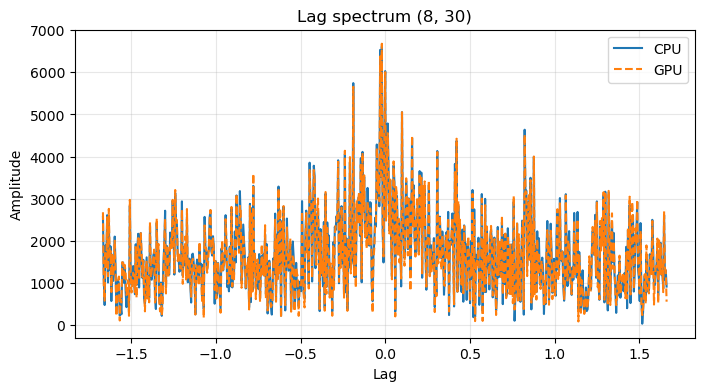

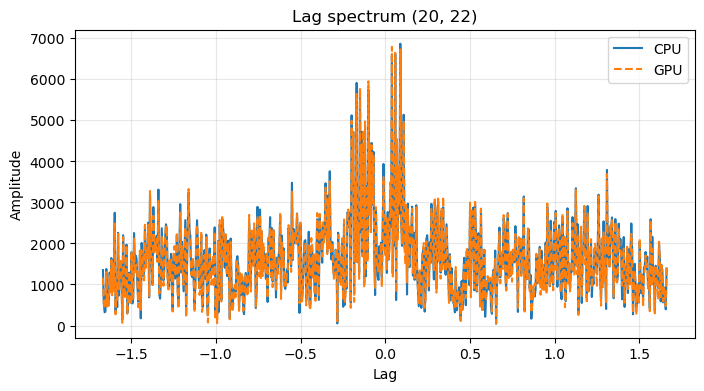

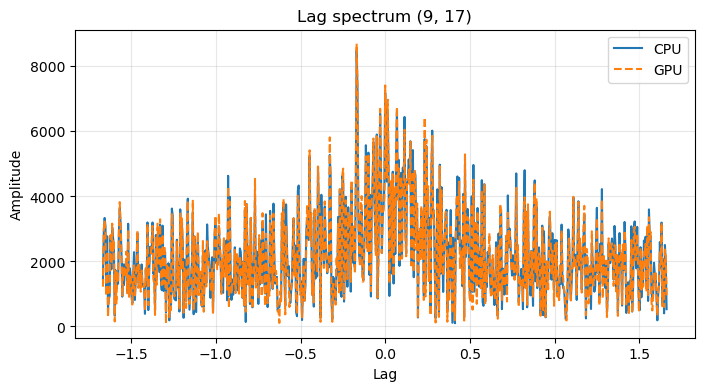

In [54]:
import numpy as np
import matplotlib.pyplot as plt

DELTA_FREQ = 0.3   # MHz

for pair, _, _, _ in results_sorted[:20]:
    cpu = cpu_dict[pair]
    gpu = gpu_dict[pair]
    cpu = np.nan_to_num(cpu)
    gpu = np.nan_to_num(gpu)
    lag_cpu = np.fft.fftshift(np.fft.ifft(cpu))
    lag_gpu = np.fft.fftshift(np.fft.ifft(gpu))
    lags = np.fft.fftshift(np.fft.fftfreq(len(cpu), d=DELTA_FREQ))

    amp_cpu = np.abs(lag_cpu)
    amp_gpu = np.abs(lag_gpu)

    #amp_cpu = 20 * np.log10(amp_cpu + 1e-12)
   # amp_gpu = 20 * np.log10(amp_gpu + 1e-12)

    plt.figure(figsize=(8,4))

    plt.plot(lags, amp_cpu, label="CPU")
    plt.plot(lags, amp_gpu, "--", label="GPU")

    plt.xlabel("Lag")
    plt.ylabel("Amplitude")
    plt.title(f"Lag spectrum {pair}")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

Calculating correlations and plotting...


KeyError: (10, 8)

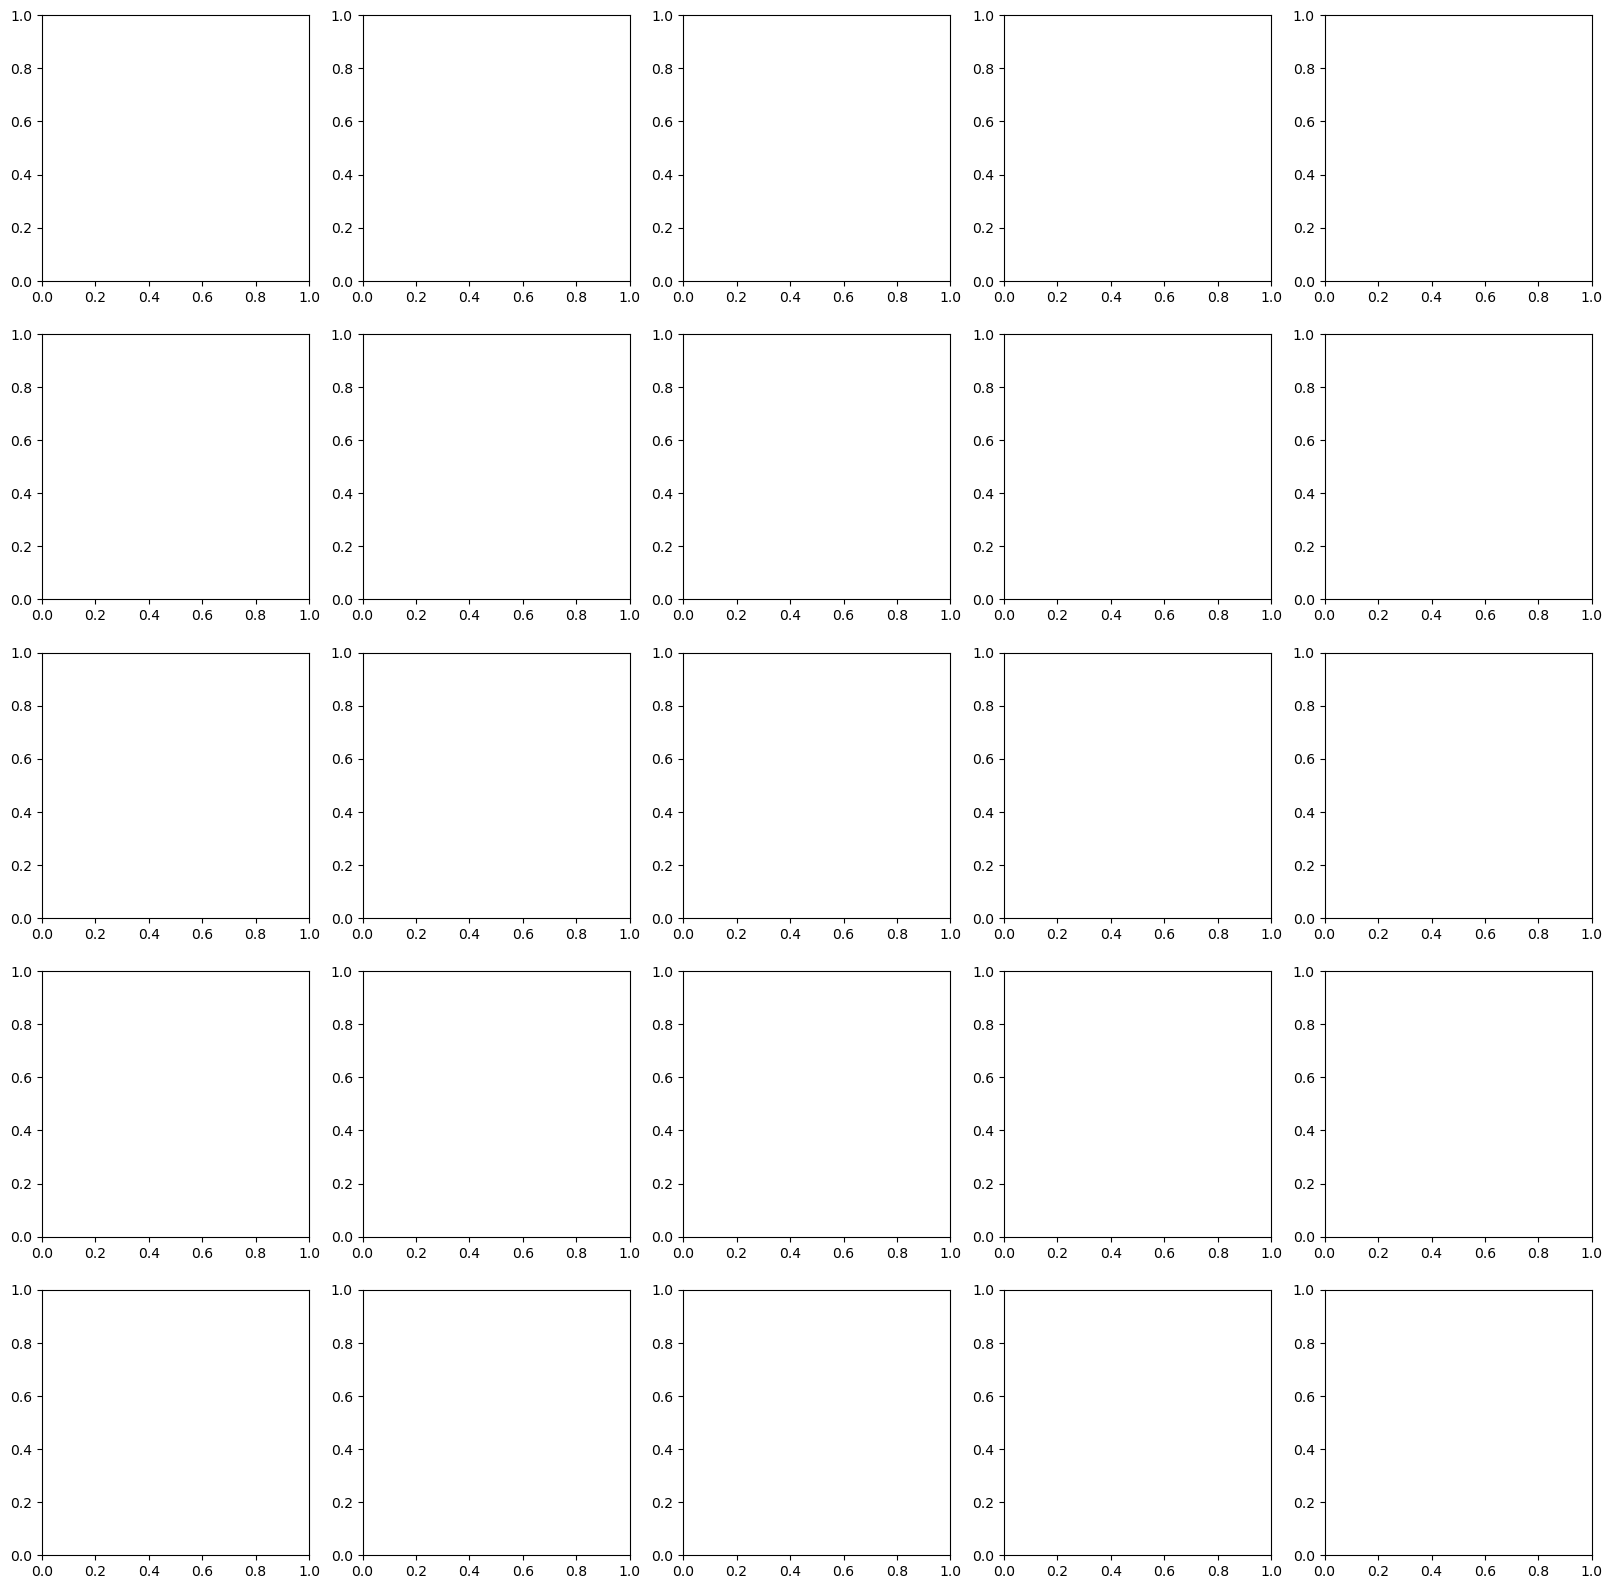

In [62]:
import numpy as np
import matplotlib.pyplot as plt

i = 10   # antena fija
n_ant = 32

# eje de frecuencias
frequencies = np.arange(NUM_FREQ)   # o el eje real si ya lo tienes

# columnas y filas
n_cols = 5
n_pairs = len(range(8, n_ant))
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

print("Calculating correlations and plotting...")

plot_idx = 0
for j in range(8, n_ant):
    pair = (i, j)

    if pair not in cpu_dict:
        continue

    corr_spectrum = gpu_dict[pair]
    phase = np.angle(corr_spectrum)

    ax = axes_flat[plot_idx]
    ax.scatter(frequencies, phase, s=3)
    ax.set_title(f"Ant {i} vs Ant {j}", fontsize=10)

    if plot_idx >= n_pairs - n_cols:
        ax.set_xlabel("Frequency [MHz]", fontsize=8)

    if plot_idx % n_cols == 0:
        ax.set_ylabel("Phase [rad]", fontsize=8)

    ax.grid(True, alpha=0.3)

    plot_idx += 1

# ocultar ejes vacíos
for k in range(plot_idx, len(axes_flat)):
    axes_flat[k].axis("off")

plt.tight_layout()
plt.show()